In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder


In [2]:
hame = []
directory = "D:\Prog\Python Codes\Football\Fotmob"
for filename in os.listdir(directory):
    if filename.endswith(".csv"):
        filepath = os.path.join(directory, filename)
        league_names = filename.split("_20")[0]
        df = pd.read_csv(filepath)
        df["league_name"] = league_names
        hame.append(df)
data = pd.concat(hame, axis=0)
data.head()


,match_date,league_name,matchid,home_team,away_team,home_probability_win,draw_probability,away_probability_win,home_goals,away_goals,...,away_interceptions,away_blocks,away_clearances,away_keeper_save,away_duels_won,away_geround_duels_won,away_aerial_duels_won,away_successful_dribbles,away_yellow_cards,away_red_cards
0,2021-04-14,afc_champions_league,3570132,Persepolis,Al-Wahda,0.802575,0.077706,0.119719,1,0,...,11,2,10,2,40,40,47,33,2,0
1,2021-04-14,afc_champions_league,3535208,Pakhtakor Tashkent,Tractor,0.396330,0.182228,0.421442,3,3,...,11,2,13,2,43,48,42,54,4,0
2,2021-04-14,afc_champions_league,3535235,FC Goa,Al-Rayyan,0.370152,0.231029,0.398820,0,0,...,5,1,9,1,39,49,71,76,3,0
3,2021-04-14,afc_champions_league,3571780,Al-Sadd,Foolad Khouzestan,0.528834,0.161883,0.309284,1,1,...,13,6,20,3,52,47,50,40,2,0
4,2021-04-14,afc_champions_league,3535229,Al-Wehdat,Al Nassr FC,0.282160,0.382213,0.335627,0,0,...,11,0,2,1,33,35,46,14,0,0


In [3]:
data.shape


(78772, 73)

In [75]:
list_of_drop_cols = ['home_ball_possession', 'home_accurate_passes', 'home_fouls_commited', 'home_shots_off_target',
                     'home_blocked_shots', 'home_hit_woodwork', 'home_shots_outside_box', 'home_passes', 'home_own_half',
                     'home_opposition_half', 'home_accurate_long_balls', 'home_accurate_crosses', 'home_throws', 'home_offsides', 'home_tackles_won', 'home_interceptions',
                     'home_blocks', 'home_clearances', 'home_duels_won', 'home_geround_duels_won', 'home_aerial_duels_won', 'home_successful_dribbles', 'home_yellow_cards', 'away_ball_possession',
                     'away_accurate_passes', 'away_fouls_commited', 'away_shots_off_target', 'away_blocked_shots', 'away_hit_woodwork', 'away_shots_outside_box',
                     'away_passes', 'away_own_half', 'away_opposition_half', 'away_accurate_long_balls', 'away_axxurate_crosses',
                     'away_throws', 'away_offsides', 'away_tackles_won', 'away_interceptions', 'away_blocks', 'away_clearances', 'away_duels_won',
                     'away_geround_duels_won', 'away_aerial_duels_won', 'away_successful_dribbles', 'away_yellow_cards', 'matchid',
                     ]
data.drop(list_of_drop_cols, axis=1, inplace=True)
data.shape


(66042, 26)

In [76]:
data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 66042 entries, 0 to 131
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   match_date             66042 non-null  object 
 1   league_name            66042 non-null  object 
 2   home_team              66042 non-null  object 
 3   away_team              66042 non-null  object 
 4   home_probability_win   60312 non-null  float64
 5   draw_probability       60312 non-null  float64
 6   away_probability_win   60312 non-null  float64
 7   home_goals             66042 non-null  int64  
 8   away_goals             66042 non-null  int64  
 9   ftr                    66042 non-null  int64  
 10  home_total_shots       66042 non-null  int64  
 11  home_shots_on_target   66042 non-null  int64  
 12  home_big_chances       66042 non-null  int64  
 13  home_big_misses        66042 non-null  int64  
 14  home_corners           66042 non-null  int64  
 15  home_shot

In [77]:
data.describe()


,home_probability_win,draw_probability,away_probability_win,home_goals,away_goals,ftr,home_total_shots,home_shots_on_target,home_big_chances,home_big_misses,...,home_keeper_save,home_red_cards,away_total_shots,away_shots_on_target,away_big_chances,away_big_misses,away_corners,away_shots_inside_box,away_keeper_save,away_red_cards
count,60312.000000,60312.000000,60312.000000,66042.000000,66042.000000,66042.000000,66042.000000,66042.000000,66042.000000,66042.000000,...,66042.000000,66042.000000,66042.000000,66042.000000,66042.000000,66042.000000,66042.000000,66042.000000,66042.000000,66042.000000
mean,0.446822,0.338479,0.214699,1.493171,1.197571,0.866736,13.342842,4.661882,1.910951,1.103464,...,2.676963,0.065413,11.227340,3.890191,1.564732,0.913373,4.497744,6.759380,3.151252,0.077678
std,0.145697,0.080651,0.124360,1.284062,1.155064,0.851366,5.237743,2.524698,1.657548,1.209420,...,1.847022,0.264591,4.790856,2.303338,1.486083,1.086494,2.631638,3.637521,2.022272,0.285884
min,0.000000,0.000000,0.000174,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.336335,0.288159,0.118546,1.000000,0.000000,0.000000,10.000000,3.000000,1.000000,0.000000,...,1.000000,0.000000,8.000000,2.000000,0.000000,0.000000,3.000000,4.000000,2.000000,0.000000
50%,0.449734,0.349658,0.178255,1.000000,1.000000,1.000000,13.000000,4.000000,2.000000,1.000000,...,2.000000,0.000000,11.000000,4.000000,1.000000,1.000000,4.000000,6.000000,3.000000,0.000000
75%,0.552249,0.398702,0.284014,2.000000,2.000000,2.000000,16.000000,6.000000,3.000000,2.000000,...,4.000000,0.000000,14.000000,5.000000,2.000000,1.000000,6.000000,9.000000,4.000000,0.000000
max,0.923333,0.833333,1.000000,13.000000,13.000000,2.000000,46.000000,25.000000,13.000000,10.000000,...,17.000000,4.000000,45.000000,23.000000,13.000000,9.000000,22.000000,31.000000,19.000000,4.000000


In [78]:
data.isnull().sum()


match_date                  0
league_name                 0
home_team                   0
away_team                   0
home_probability_win     5730
draw_probability         5730
away_probability_win     5730
home_goals                  0
away_goals                  0
ftr                         0
home_total_shots            0
home_shots_on_target        0
home_big_chances            0
home_big_misses             0
home_corners                0
home_shots_inside_box       0
home_keeper_save            0
home_red_cards              0
away_total_shots            0
away_shots_on_target        0
away_big_chances            0
away_big_misses             0
away_corners                0
away_shots_inside_box       0
away_keeper_save            0
away_red_cards              0
dtype: int64

In [4]:
home_win_null = data.apply(lambda row: 0.5 if row["home_goals"] > row["away_goals"] else (
    0.25 if row["home_goals"] == row["away_goals"] else 0.25), axis=1)
draw_null = data.apply(
    lambda row: 0.5 if row["home_goals"] == row["away_goals"] else 0, axis=1)
away_win_null = data.apply(lambda row: 0.5 if row["home_goals"] < row["away_goals"] else (
    0.25 if row["home_goals"] == row["away_goals"] else 0.25), axis=1)

data['home_probability_win'].fillna(home_win_null, inplace=True)
data['draw_probability'].fillna(draw_null, inplace=True)
data['away_probability_win'].fillna(away_win_null, inplace=True)


In [5]:
import datetime

data['match_date'] = pd.to_datetime(data['match_date'])

def get_weights(data):
    now = datetime.datetime.now()
    weight = 1.0 / (1 + (now - data['match_date']).dt.days / 365)
    return weight


weight = get_weights(data)
data.drop('match_date', axis=1, inplace=True)
data.head()


,league_name,matchid,home_team,away_team,home_probability_win,draw_probability,away_probability_win,home_goals,away_goals,ftr,...,away_interceptions,away_blocks,away_clearances,away_keeper_save,away_duels_won,away_geround_duels_won,away_aerial_duels_won,away_successful_dribbles,away_yellow_cards,away_red_cards
0,afc_champions_league,3570132,Persepolis,Al-Wahda,0.802575,0.077706,0.119719,1,0,0,...,11,2,10,2,40,40,47,33,2,0
1,afc_champions_league,3535208,Pakhtakor Tashkent,Tractor,0.396330,0.182228,0.421442,3,3,1,...,11,2,13,2,43,48,42,54,4,0
2,afc_champions_league,3535235,FC Goa,Al-Rayyan,0.370152,0.231029,0.398820,0,0,1,...,5,1,9,1,39,49,71,76,3,0
3,afc_champions_league,3571780,Al-Sadd,Foolad Khouzestan,0.528834,0.161883,0.309284,1,1,1,...,13,6,20,3,52,47,50,40,2,0
4,afc_champions_league,3535229,Al-Wehdat,Al Nassr FC,0.282160,0.382213,0.335627,0,0,1,...,11,0,2,1,33,35,46,14,0,0


In [6]:
dd = data[['league_name', 'home_team', 'away_team']]
data.drop(['league_name', 'home_team', 'away_team'], axis=1, inplace=True)
data.head()


,matchid,home_probability_win,draw_probability,away_probability_win,home_goals,away_goals,ftr,home_ball_possession,home_total_shots,home_shots_on_target,...,away_interceptions,away_blocks,away_clearances,away_keeper_save,away_duels_won,away_geround_duels_won,away_aerial_duels_won,away_successful_dribbles,away_yellow_cards,away_red_cards
0,3570132,0.802575,0.077706,0.119719,1,0,0,59,9,4,...,11,2,10,2,40,40,47,33,2,0
1,3535208,0.396330,0.182228,0.421442,3,3,1,51,10,6,...,11,2,13,2,43,48,42,54,4,0
2,3535235,0.370152,0.231029,0.398820,0,0,1,44,3,1,...,5,1,9,1,39,49,71,76,3,0
3,3571780,0.528834,0.161883,0.309284,1,1,1,66,19,4,...,13,6,20,3,52,47,50,40,2,0
4,3535229,0.282160,0.382213,0.335627,0,0,1,33,4,1,...,11,0,2,1,33,35,46,14,0,0


<Axes: >

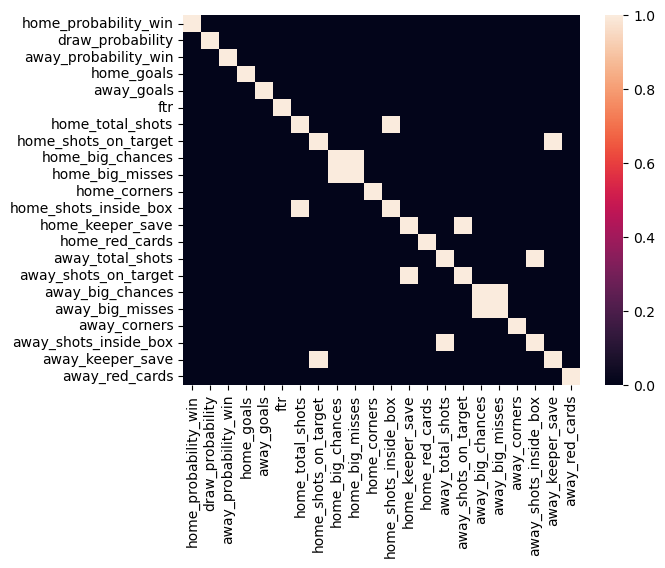

In [82]:
sns.heatmap(data.corr() > 0.7)


In [ ]:
data.drop(['home_shots_inside_box', 'away_shots_inside_box',
          'home_keeper_save', 'away_keeper_save', 'home_big_misses', 'away_big_misses', 'home_shots_inside_box', 'away_shots_inside_box',
           'home_goals', 'away_goals', 'home_corners', 'away_corners', 'home_shots_on_target', 'away_shots_on_target'],
          axis=1, inplace=True)


C:\Users\moomad\AppData\Local\Temp\ipykernel_7296\3230591350.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['away_probability_win'])


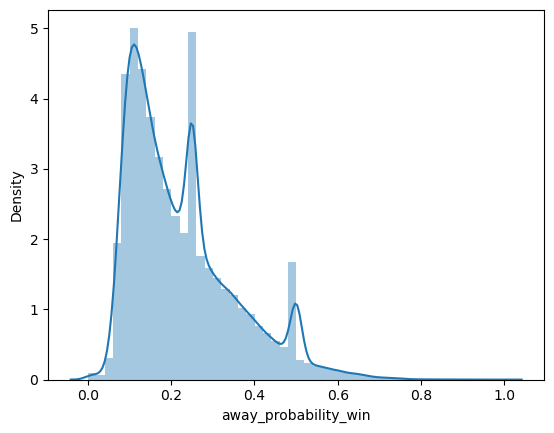

In [ ]:
sns.distplot(data['away_probability_win'])
plt.show()


In [85]:
y = data['ftr']
ss = StandardScaler()
data.iloc[:, :] = ss.fit_transform(data.iloc[:, :])
X = data.drop('ftr', axis=1)
data.head()


,home_probability_win,draw_probability,away_probability_win,ftr,home_total_shots,home_big_chances,home_red_cards,away_total_shots,away_big_chances,away_red_cards
0,2.488433,-2.066695,-0.820750,-1.018061,-0.829150,0.657029,-0.247225,-0.673651,-1.052931,-0.271713
1,-0.298147,-1.173225,1.548994,0.156530,-0.638227,0.053724,-0.247225,0.161279,0.965814,-0.271713
2,-0.477710,-0.756068,1.371314,0.156530,-1.974691,-1.152887,-0.247225,0.161279,0.292899,-0.271713
3,0.610746,-1.347141,0.668096,0.156530,1.080084,-0.549581,-0.247225,0.787477,-0.380016,-0.271713
4,-1.081278,0.536280,0.875000,0.156530,-1.783767,-1.152887,-0.247225,-0.464918,-0.380016,-0.271713


In [86]:
y


0      0
1      1
2      1
3      1
4      1
      ..
127    2
128    2
129    0
130    2
131    1
Name: ftr, Length: 66042, dtype: int64

In [87]:
new_data = pd.concat([X, dd], axis=1)

X = pd.get_dummies(new_data, columns=[
                   'league_name', 'home_team', 'away_team'], dtype=int)


In [88]:
X.shape


(66042, 3270)

In [89]:
y.value_counts()


ftr
0    28921
2    20120
1    17001
Name: count, dtype: int64

In [8]:
dfs = data[['home_probability_win','draw_probability','away_probability_win', 'ftr']]
dfs.head()


,home_probability_win,draw_probability,away_probability_win,ftr
0,0.802575,0.077706,0.119719,0
1,0.396330,0.182228,0.421442,1
2,0.370152,0.231029,0.398820,1
3,0.528834,0.161883,0.309284,1
4,0.282160,0.382213,0.335627,1


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score



In [11]:
x_train, x_test, y_train, y_test = train_test_split(dfs.drop('ftr', axis=1), dfs['ftr'], random_state=12)


In [12]:
model = LogisticRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
acc = accuracy_score(y_test, y_pred)
acc


0.5073489384866631

In [13]:
y_test


126    2
56     0
86     1
31     2
456    1
      ..
133    2
51     0
267    0
303    0
7      2
Name: ftr, Length: 16533, dtype: int64

In [14]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)


In [15]:
y_test


array([[0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       ...,
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.]], dtype=float32)

In [16]:
weight_dict = weight.to_dict()
weight_dict


{0: 0.3878852284803401,
 1: 0.3882978723404255,
 2: 0.3887113951011715,
 3: 0.3887113951011715,
 4: 0.3887113951011715,
 5: 0.3887113951011715,
 6: 0.3912111468381565,
 7: 0.3916309012875537,
 8: 0.3916309012875537,
 9: 0.3916309012875537,
 10: 0.3916309012875537,
 11: 0.3916309012875537,
 12: 0.3928955866523143,
 13: 0.3933189655172413,
 14: 0.40021929824561403,
 15: 0.4006586169045005,
 16: 0.4006586169045005,
 17: 0.4006586169045005,
 18: 0.4006586169045005,
 19: 0.4006586169045005,
 20: 0.40331491712707185,
 21: 0.40331491712707185,
 22: 0.40376106194690264,
 23: 0.40376106194690264,
 24: 0.40376106194690264,
 25: 0.40376106194690264,
 26: 0.40691192865105913,
 27: 0.40691192865105913,
 28: 0.40691192865105913,
 29: 0.40691192865105913,
 30: 0.40691192865105913,
 31: 0.40691192865105913,
 32: 0.4101123595505618,
 33: 0.4101123595505618,
 34: 0.4101123595505618,
 35: 0.4101123595505618,
 36: 0.4101123595505618,
 37: 0.4161915621436716,
 38: 0.4161915621436716,
 39: 0.416666666666666

In [17]:
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential

model = Sequential()
model.add(Dense(32, activation='relu', input_shape=(x_train.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.5))
model.add(BatchNormalization())
model.add(Dense(8, activation='relu'))
model.add(Dense(3, activation='softmax'))
model.compile(optimizer='adam', loss='categorical_crossentropy',
              metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=20,
                    batch_size=32, validation_data=(x_test, y_test),
                    # class_weight=weight_dict
                    )




Epoch 1/20


1550/1550 [==============================] - 19s 8ms/step - loss: 1.0117 - accuracy: 0.4904 - val_loss: 0.9693 - val_accuracy: 0.5271
Epoch 2/20
1550/1550 [==============================] - 16s 10ms/step - loss: 0.9917 - accuracy: 0.5094 - val_loss: 0.9671 - val_accuracy: 0.5311
Epoch 3/20
1550/1550 [==============================] - 13s 9ms/step - loss: 0.9864 - accuracy: 0.5082 - val_loss: 0.9526 - val_accuracy: 0.5308
Epoch 4/20
1550/1550 [==============================] - 15s 10ms/step - loss: 0.9859 - accuracy: 0.5071 - val_loss: 0.9620 - val_accuracy: 0.5287
Epoch 5/20
1550/1550 [==============================] - 17s 11ms/step - loss: 0.9918 - accuracy: 0.5025 - val_loss: 0.9719 - val_accuracy: 0.5122
Epoch 6/20
1550/1550 [==============================] - 18s 12ms/step - loss: 0.9941 - accuracy: 0.4985 - val_loss: 0.9734 - val_accuracy: 0.5126
Epoch 7/20
1550/1550 [==============================] - 21s 13ms/step - loss: 0.9918 - accuracy: 0.4982 - val_loss: 0.9779

In [22]:
pr = np.zeros([1, 3], dtype=int)
prediction = pd.DataFrame(
    pr, columns=['home_probability_win', 'draw_probability', 'away_probability_win'])


In [25]:
# prediction['league_name_primier_league_england'] = 1
# prediction['home_team_Everton'] = 1
# prediction['away_team_Liverpool'] = 1
prediction['home_probability_win'] = 0.1
prediction['away_probability_win'] = 0.1
prediction['draw_probability'] = 0.8
pm = model.predict(prediction)
print(pm)


1/1 [==============================] - 0s 78ms/step
[[0.5391175  0.29969007 0.16119236]]
